In [5]:
import joblib
loader_model=joblib.load(open('logistic_regression_model.sav','rb'))

In [6]:
import numpy as np
from sklearn.preprocessing import StandardScaler
import pickle

with open('scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

#std_data = scaler.transform(input_data_reshaped)


In [7]:
# input_data=(1,1,0,1,1,1,1,1,1,1,20,0,1,0,1,0)
# input_data_as_numpy_array=np.asarray(input_data)
# input_data_reshaped=input_data_as_numpy_array.reshape(1,-1)
# std_data=scaler.transform(input_data_reshaped)
# #print(std_data)
# prediction=loader_model.predict(std_data)
# print(prediction)
# if prediction[0] == 0:
#     print('Patient is non ASD')
# else:
#     print('Patient is ASD')

In [8]:
import json

with open("class_names.json", "r") as f:
    class_names = json.load(f)

In [9]:
# import tensorflow as tf
# import numpy as np
# import matplotlib.pyplot as plt

# # Load the saved model
# model = tf.keras.models.load_model(
#     r"C:\Users\HP\OneDrive\Desktop\ASD\ASD\asd_cnn_model.keras"
# )

# # Load and display image
# img = tf.keras.utils.load_img(
#     r"C:\Users\HP\OneDrive\Desktop\ASD\ASD\AutismDataset\test\Autistic.1.jpg",
#     target_size=(224, 224)
# )

# plt.imshow(img)
# plt.axis('off')
# plt.show()

# # Convert image to array
# img_array = tf.keras.utils.img_to_array(img)
# img_array = tf.expand_dims(img_array, 0)  # batch of 1

# # Predict
# predictions = model.predict(img_array)

# # Convert logits to probabilities
# score = tf.nn.softmax(predictions[0])

# # Display result
# print(
#     "This image most likely belongs to {} with a {:.2f}% confidence."
#     .format(class_names[np.argmax(score)], 100 * np.max(score))
# )


Tabular raw prediction: [0]
Tabular Model Result: Non-ASD


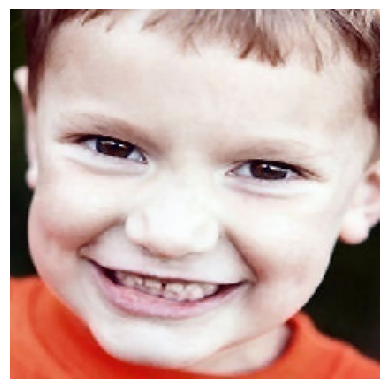

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step
Image Model Result: Non_Autistic (100.00% confidence)

FINAL RESULT: Patient is NON-ASD


In [12]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# ================= TABULAR MODEL =================
input_data = (1,1,0,0,0,1,1,0,0,0,36,1,1,1,0,0)

input_data_as_numpy_array = np.asarray(input_data)
input_data_reshaped = input_data_as_numpy_array.reshape(1, -1)

std_data = scaler.transform(input_data_reshaped)

prediction = loader_model.predict(std_data)
print("Tabular raw prediction:", prediction)

# Tabular decision
if prediction[0] == 0:
    tabular_label = "Non-ASD"
    tabular_score = 0.0
else:
    tabular_label = "ASD"
    tabular_score = 1.0

print("Tabular Model Result:", tabular_label)


# ================= IMAGE MODEL =================
model = tf.keras.models.load_model(
    r"C:\Users\HP\OneDrive\Desktop\ASD\ASD\asd_cnn_model1.keras"
)

img = tf.keras.utils.load_img(
    r"C:\Users\HP\OneDrive\Desktop\ASD\ASD\AutismDataset\test\Non_Autistic\Non_Autistic.38.jpg",
    target_size=(224, 224)
)

plt.imshow(img)
plt.axis('off')
plt.show()

img_array = tf.keras.utils.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)

predictions = model.predict(img_array)
score = tf.nn.softmax(predictions[0])

image_label = class_names[np.argmax(score)]
image_score = np.max(score)

print(
    f"Image Model Result: {image_label} "
    f"({image_score*100:.2f}% confidence)"
)


# ================= COMBINED RESULT =================
final_score = (tabular_score + image_score) / 2

if final_score >= 0.5:
    print(f"\nFINAL RESULT: Patient is ASD")
else:
    print(f"\nFINAL RESULT: Patient is NON-ASD")
